# Week 2｜Sklearn 文本分类实验

## 20 Newsgroups：从原始文本到模型评估

> **本实验目标**：理解监督学习的完整链路：原始文本 → TF-IDF 特征 → 训练/测试划分 → 模型训练 → 指标与可视化。

**本周产出**：模型对比表、混淆矩阵、二分类 ROC 曲线，以及一段对实验结果的分析。

---
## 0｜环境与科研魔法命令

先运行本格。`%matplotlib inline` 让图表嵌在 Notebook 中；`autoreload` 在后续把函数写入外部 `.py` 文件时很有用。

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
sns.set_theme(style='whitegrid', palette='deep')

Python: 3.11.7
NumPy: 2.4.6


## 1｜机器学习流程图

```text
训练文本 ──→ TF-IDF 向量化 ──→ 分类器拟合 ──→ 在未见过的测试集评估
                    ↑                    │
              只在训练集 fit              └── 预测类别 / 概率
```

**关键原则：**测试集只在最后评估一次；在测试集上不断调参数会造成“看答案训练”，即数据泄露。

# 自测｜请在此填写

训练集用于：让模型学习数据中的规律，并调整模型参数。

验证集用于：在训练过程中调参、选择模型，以及观察是否过拟合。

测试集用于：在模型和参数都确定后，独立评估最终泛化能力。

过拟合表示：模型把训练数据记得过细，训练表现很好，但在新数据上的表现较差。

---
## 2｜加载 20 Newsgroups 数据

选择四个类别。第一次运行会下载数据；`remove` 删除邮件头、页脚和引用内容，减少模型从无关格式中“投机取巧”。

In [2]:
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.med', 'talk.politics.guns', 'rec.sport.baseball', 'comp.graphics']
dataset = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42,
)

X_text = dataset.data       # Python 列表：每个元素是一篇原始文本
y = dataset.target          # NumPy 数组：每篇文本对应的类别编号

print('文本数量:', len(X_text))
print('类别名称:', dataset.target_names)
print('类别分布:', np.bincount(y))
print('\n第一条文本片段：\n', X_text[0][:500])

文本数量: 3867
类别名称: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.guns']
类别分布: [973 994 990 910]

第一条文本片段：
 
A book that I can somewhat recommend is :
                     
                     Pratical Image Processing in C
                     by Craig A. Lindley
                     published by Wiley


## 3｜TF-IDF：把文字变成数字特征

机器学习模型无法直接理解字符串。TF-IDF 将每篇文本转为一个稀疏向量：

- `max_features=10000`：最多保留 10,000 个词或短语；
- `ngram_range=(1, 2)`：同时使用单词和双词组合；
- `min_df=3`：至少出现 3 次的词才保留。

特征矩阵形状通常是 `(文本数, 特征数)`。

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
)

%time X = vectorizer.fit_transform(X_text)

print('特征矩阵形状:', X.shape)
print('稀疏矩阵类型:', type(X).__name__)
print('前 15 个特征:', vectorizer.get_feature_names_out()[:15])

CPU times: total: 1.62 s
Wall time: 1.72 s
特征矩阵形状: (3867, 10000)
稀疏矩阵类型: csr_matrix
前 15 个特征: ['00' '00 02' '000' '000 00' '000 000' '01' '01 02' '01 03' '01 05' '02'
 '02 00' '02 01' '02 02' '02 03' '02 04']


### 魔法命令练习

运行下一格，观察 `%timeit` 会重复执行并给出平均耗时。这里仅比较一个很小的数组操作，不要对完整模型训练使用 `%timeit`。

In [4]:
small_array = np.random.rand(10_000)
%timeit small_array.mean()
%whos

5.9 μs ± 176 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Variable             Type               Data/Info
-------------------------------------------------
TfidfVectorizer      type               <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                    csr_matrix         <Compressed Sparse Row sp<...>5950)	0.07863476110569917
X_text               list               n=3867
categories           list               n=4
dataset              Bunch              {'data': ['\nA book that <...>cument_clustering.py`\n'}
fetch_20newsgroups   function           <function fetch_20newsgro<...>ps at 0x0000029D9C530720>
np                   module             <module 'numpy' from 'E:\<...>ges\\numpy\\__init__.py'>
pd                   module             <module 'pandas' from 'E:<...>es\\pandas\\__init__.py'>
plt                  module             <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
small_array          ndarray            10000: 10000 elems, typ

---
## 4｜划分训练集与测试集

`stratify=y` 保证训练集和测试集的类别比例接近原始数据。随机种子固定后，实验可复现。

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('训练集:', X_train.shape, '类别分布:', np.bincount(y_train))
print('测试集:', X_test.shape, '类别分布:', np.bincount(y_test))

训练集: (3093, 10000) 类别分布: [778 795 792 728]
测试集: (774, 10000) 类别分布: [195 199 198 182]


## 5｜训练多个分类器

先从 Logistic Regression 基线开始，再比较线性 SVM。对于高维稀疏文本，线性模型往往是强而高效的基线。

为保证初学时运行稳定，本模板默认训练两个模型；可以在完成后自行加入 Random Forest 等模型比较。

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Linear SVM': SVC(kernel='linear', C=1.0, probability=True),
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'\n训练：{name}')
    start = __import__('time').perf_counter()
    model.fit(X_train, y_train)
    elapsed = __import__('time').perf_counter() - start
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    results.append({'模型': name, 'Accuracy': accuracy_score(y_test, y_pred),
                    'Macro Precision': precision, 'Macro Recall': recall,
                    'Macro F1': f1, '训练秒数': elapsed})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('Macro F1', ascending=False)
display(results_df.style.format({'Accuracy': '{:.4f}', 'Macro Precision': '{:.4f}',
                                  'Macro Recall': '{:.4f}', 'Macro F1': '{:.4f}',
                                  '训练秒数': '{:.2f}'}))


训练：Logistic Regression

训练：Linear SVM


E:\Python\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,模型,Accuracy,Macro Precision,Macro Recall,Macro F1,训练秒数
0,Logistic Regression,0.9109,0.9123,0.9112,0.9111,0.29
1,Linear SVM,0.8979,0.8995,0.8980,0.8981,23.84


## 6｜模型评估：分类报告与混淆矩阵

- **Precision（精确率）**：模型判为某类的样本中，有多少真的属于该类。
- **Recall（召回率）**：真实属于某类的样本中，模型找回了多少。
- **F1**：Precision 与 Recall 的平衡。

安全任务常格外关注 Recall，因为漏报可能比误报更危险。

最佳模型： Logistic Regression
                    precision    recall  f1-score   support

     comp.graphics       0.92      0.92      0.92       195
rec.sport.baseball       0.87      0.94      0.91       199
           sci.med       0.92      0.85      0.89       198
talk.politics.guns       0.93      0.93      0.93       182

          accuracy                           0.91       774
         macro avg       0.91      0.91      0.91       774
      weighted avg       0.91      0.91      0.91       774



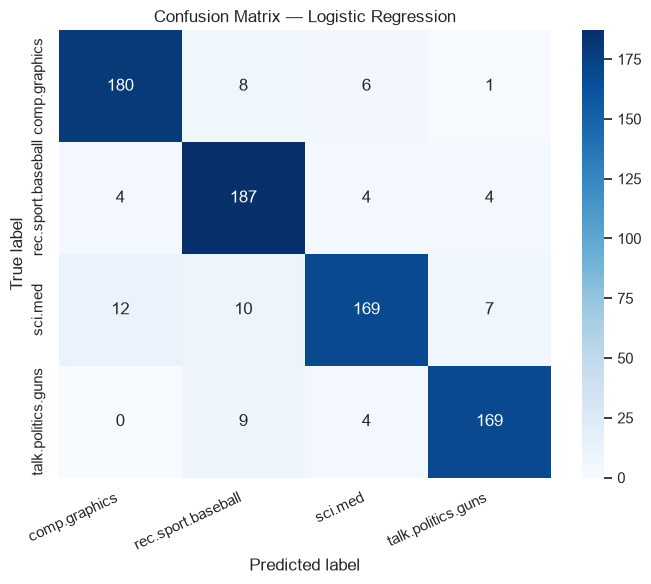

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = results_df.iloc[0]['模型']
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)

print('最佳模型：', best_name)
print(classification_report(y_test, y_pred, target_names=dataset.target_names, zero_division=0))
 
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.target_names, yticklabels=dataset.target_names, ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 7｜二分类 ROC 曲线

ROC 曲线是二分类指标。这里把问题临时改为：`sci.med` 与 `talk.politics.guns`。AUC 越接近 1 越好，随机分类器约为 0.5。

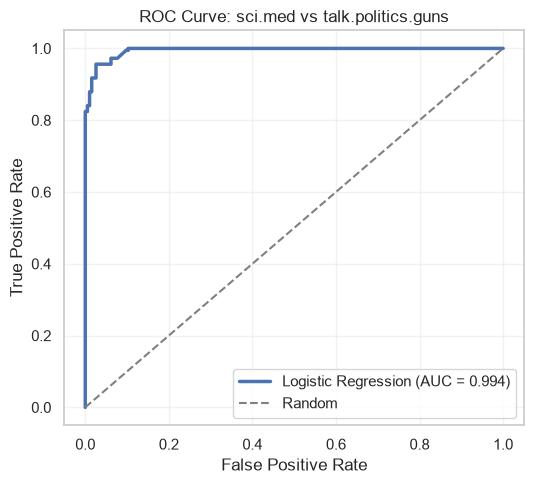

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

binary_mask = np.isin(y, [0, 3])
X_binary = X[binary_mask]
y_binary = (y[binary_mask] == 3).astype(int)  # 1：talk.politics.guns；0：sci.med

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
binary_model = LogisticRegression(max_iter=1000).fit(X_train_b, y_train_b)
y_prob = binary_model.predict_proba(X_test_b)[:, 1]
fpr, tpr, _ = roc_curve(y_test_b, y_prob)
auc = roc_auc_score(y_test_b, y_prob)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, linewidth=2.5, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: sci.med vs talk.politics.guns')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8｜Pipeline 与交叉验证

Pipeline 将“向量化 + 分类器”绑定在一起，交叉验证时每一折都只在该折训练数据上学习词表，避免数据泄露。

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=3)),
    ('clf', LogisticRegression(max_iter=1000)),
])

# 先在较小子集做 3 折交叉验证；完整实验可将 1_500 改大，并将 cv 改为 5
subset_size = min(1_500, len(X_text))
scores = cross_val_score(pipeline, X_text[:subset_size], y[:subset_size],
                         cv=3, scoring='f1_macro', n_jobs=-1)
print('3 折 F1:', np.round(scores, 4))
print(f'平均 F1: {scores.mean():.4f} ± {scores.std():.4f}')

3 折 F1: [0.8276 0.8492 0.8686]
平均 F1: 0.8485 ± 0.0168
